In [1]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, random_split
from torchvision import datasets
from torchvision.models import resnet18, ResNet18_Weights
from torchvision.models import mobilenet_v3_small, MobileNet_V3_Small_Weights

torch.manual_seed(2137)
device = torch.device("cuda" if torch.cuda.is_available() else ("mps" if torch.backends.mps.is_available() else "cpu"))
print(f"Using device: {device}")

def count_parameters(model):
    return sum(p.numel() for p in model.parameters())

def count_trainable_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

Using device: mps


In [2]:
weights = ResNet18_Weights.DEFAULT
preprocess = weights.transforms()

train_dataset = datasets.CIFAR10(root="./data", train=True, download=False, transform=preprocess)
test_dataset = datasets.CIFAR10(root="./data", train=False, download=False, transform=preprocess)

train_size = int(0.9 * len(train_dataset))
val_size = len(train_dataset) - train_size
train_subset, val_subset = random_split(train_dataset, [train_size, val_size])

train_loader = DataLoader(train_subset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_subset, batch_size=64, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

/Users/zoga/Studia-II/Neural-Networks/.venv/lib/python3.14/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


# Task1

## RESNET

In [ ]:
resnet18(weights=ResNet18_Weights.DEFAULT) # model

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [ ]:
ResNet18_Weights.DEFAULT.transforms() # transformacje

ImageClassification(
    crop_size=[224]
    resize_size=[256]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BILINEAR
)

In [ ]:
resnet = resnet18(weights=ResNet18_Weights.DEFAULT)

num_features_resnet = resnet.fc.in_features

resnet.fc = nn.Linear(num_features_resnet, 10)
resnet = resnet.to(device)

print(f"Total params: {count_parameters(resnet):,}")
print(f"Classifier layer replaced at: 'model.fc'")

Total params: 11,181,642
Classifier layer replaced at: 'model.fc'


## MOBILENET V3 SMALL

In [ ]:
mobilenet_v3_small(weights=MobileNet_V3_Small_Weights.DEFAULT) # model

MobileNetV3(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
      (2): Hardswish()
    )
    (1): InvertedResidual(
      (block): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(16, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), groups=16, bias=False)
          (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
          (2): ReLU(inplace=True)
        )
        (1): SqueezeExcitation(
          (avgpool): AdaptiveAvgPool2d(output_size=1)
          (fc1): Conv2d(16, 8, kernel_size=(1, 1), stride=(1, 1))
          (fc2): Conv2d(8, 16, kernel_size=(1, 1), stride=(1, 1))
          (activation): ReLU()
          (scale_activation): Hardsigmoid()
        )
        (2): Conv2dNormActivation(
          (0): Conv2d(16, 16, kernel_size=(1, 1), 

In [7]:
MobileNet_V3_Small_Weights.DEFAULT.transforms() # transfomracje

ImageClassification(
    crop_size=[224]
    resize_size=[256]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BILINEAR
)

In [8]:
mobilenet = mobilenet_v3_small(weights=MobileNet_V3_Small_Weights.DEFAULT)

num_features_mobile = mobilenet.classifier[3].in_features

mobilenet.classifier[3] = nn.Linear(num_features_mobile, 10)
mobilenet = mobilenet.to(device)

print(f"Total params: {count_parameters(mobilenet):,}")
print(f"Classifier layer replaced at: 'model.classifier[3]'")

Total params: 1,528,106
Classifier layer replaced at: 'model.classifier[3]'


## Test

In [21]:
dummy_batch = torch.randn(16, 3, 32, 32).to(device) # Batch: 16 obrazków

out_resnet = resnet(dummy_batch)
out_mobilenet = mobilenet(dummy_batch)

print(f"ResNet output shape: {out_resnet.shape} (Expected: 16, 10)")
print(f"MobileNet output shape: {out_mobilenet.shape} (Expected: 16, 10)")

ResNet output shape: torch.Size([16, 10]) (Expected: 16, 10)
MobileNet output shape: torch.Size([16, 10]) (Expected: 16, 10)


## Required discussion

Explain:

* why the original classifier must be replaced,
    * Because it doesn't fit our shape. Also, we want to do transfer learning, so we want to use the backbone of the model and only change the decision part. The model was trained on ImageNet with 1000 classes, and we have only 10 classes.
* why pretrained models need their own preprocessing,
    * NNs are really sensitive to data distribution. To have any use of a pretrained architecture, we need to fit our data into its initial distribution.
* why different architectures expose the final classifier in different places,
    * ResNet's structure is simple and its classifier is at the end, but for example, MobileNet has a more complex structure, and to keep it clearer to use, they put it elsewhere.
* which of the two models seems more convenient for CIFAR-10 on your hardware.
    * MobileNetV3 has only 1.5 mln parameters and ResNet18 has 11.1 mln, so MobileNet, of course.

# Task 2

In [31]:
import wandb
import torch.optim as optim
import matplotlib.pyplot as plt

weights = MobileNet_V3_Small_Weights.DEFAULT
model_frozen = mobilenet_v3_small(weights=weights)

for param in model_frozen.parameters():
    param.requires_grad = False

num_features = model_frozen.classifier[3].in_features
model_frozen.classifier[3] = nn.Linear(num_features, 10)
model_frozen = model_frozen.to(device)

print(f"Total parameters: {count_parameters(model_frozen):,}")
print(f"Trainable parameters: {count_trainable_parameters(model_frozen):,}")


Total parameters: 1,528,106
Trainable parameters: 10,250


In [28]:
epochs = 3
optimizer = optim.Adam(model_frozen.classifier.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

run = wandb.init(
    project="nn-assignment-6",
    name="mobilenet_frozen",
    config={
        "model": "mobilenet_v3_small",
        "epochs": epochs,
        "batch_size": 64,
        "lr": 0.001,
        "setup": "frozen_backbone"
    }
)

hist_frozen = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /Users/zoga/.netrc.
wandb: Currently logged in as: wiktor-zoga (wiktor-zoga-uwr) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


In [29]:
print("\nRozpoczynamy trening z zamrożonym backbone'em...")
for epoch in range(epochs):
    # TRAIN
    model_frozen.train()
    total_train_loss, correct_train, samples_train = 0.0, 0, 0
    for x, y in train_loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        logits = model_frozen(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()
        
        total_train_loss += loss.item() * x.size(0)
        correct_train += (logits.argmax(dim=1) == y).sum().item()
        samples_train += x.size(0)
        
    train_loss = total_train_loss / samples_train
    train_acc = correct_train / samples_train
    
    # EVAL
    model_frozen.eval()
    total_val_loss, correct_val, samples_val = 0.0, 0, 0
    with torch.no_grad():
        for x, y in val_loader:
            x, y = x.to(device), y.to(device)
            logits = model_frozen(x)
            loss = criterion(logits, y)
            
            total_val_loss += loss.item() * x.size(0)
            correct_val += (logits.argmax(dim=1) == y).sum().item()
            samples_val += x.size(0)
            
    val_loss = total_val_loss / samples_val
    val_acc = correct_val / samples_val
    
    # Logowanie wyników
    hist_frozen['train_loss'].append(train_loss)
    hist_frozen['val_loss'].append(val_loss)
    hist_frozen['train_acc'].append(train_acc)
    hist_frozen['val_acc'].append(val_acc)
    
    # Wysyłanie metryk do W&B
    wandb.log({
        "epoch": epoch + 1,
        "train_loss": train_loss,
        "val_loss": val_loss,
        "train_acc": train_acc,
        "val_acc": val_acc
    })
    
    print(f"Epoch {epoch+1}/{epochs} | Train Loss: {train_loss:.4f} | Val Acc: {val_acc:.4f}")

run.finish()


Rozpoczynamy trening z zamrożonym backbone'em...
Epoch 1/3 | Train Loss: 0.7369 | Val Acc: 0.7926
Epoch 2/3 | Train Loss: 0.5597 | Val Acc: 0.8264
Epoch 3/3 | Train Loss: 0.5357 | Val Acc: 0.8270


epoch,▁▅█
train_acc,▁▇█
train_loss,█▂▁
val_acc,▁██
val_loss,█▂▁
epoch,3
train_acc,0.81542
train_loss,0.53573
val_acc,0.827
val_loss,0.48795


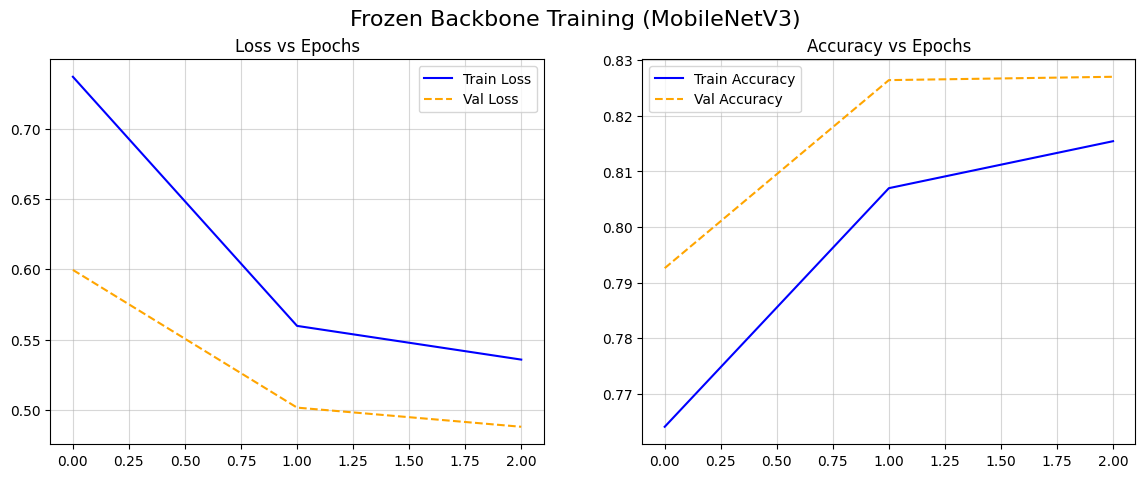


Final Validation Accuracy: 0.8270


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Frozen Backbone Training (MobileNetV3)", fontsize=16)

axes[0].plot(hist_frozen['train_loss'], label='Train Loss', color='blue')
axes[0].plot(hist_frozen['val_loss'], label='Val Loss', color='orange', linestyle='--')
axes[0].set_title('Loss vs Epochs')
axes[0].legend()
axes[0].grid(True, alpha=0.5)

axes[1].plot(hist_frozen['train_acc'], label='Train Accuracy', color='blue')
axes[1].plot(hist_frozen['val_acc'], label='Val Accuracy', color='orange', linestyle='--')
axes[1].set_title('Accuracy vs Epochs')
axes[1].legend()
axes[1].grid(True, alpha=0.5)

plt.show()

print(f"\nFinal Validation Accuracy: {hist_frozen['val_acc'][-1]:.4f}")

### Required explanation (Task 2)

* **What is frozen and what remains trainable:**
  The entire convolutional feature extractor (the "backbone") is frozen. This means `requires_grad` is set to `False` for all its parameters, preventing them from being updated during backpropagation. The only part that remains trainable is the newly initialized final linear layer (the classification head), which maps the extracted features to our 10 CIFAR-10 classes.

* **Why this setup is called transfer learning:**
  It is called transfer learning because we are taking the generalized knowledge (patterns, edges, shapes, and high-level concepts) that the model previously learned from a massive dataset (ImageNet) and transferring it to a new, smaller target task (CIFAR-10). Instead of learning how to "see" from scratch, the network only learns how to map already recognized patterns to our specific categories.

* **Why this setup is cheaper than training the full model:**
  This setup is computationally much cheaper because we do not need to calculate gradients or perform weight updates for the millions of parameters in the deep layers of the network. The backward pass stops at the final layer, saving enormous amounts of memory and processing time.

# Task 3

In [33]:
import time
import pandas as pd

weights = MobileNet_V3_Small_Weights.DEFAULT
model_finetune = mobilenet_v3_small(weights=weights)

num_features = model_finetune.classifier[3].in_features
model_finetune.classifier[3] = nn.Linear(num_features, 10)
model_finetune = model_finetune.to(device)

print(f"Total parameters: {count_parameters(model_finetune):,}")
print(f"Trainable parameters: {count_trainable_parameters(model_finetune):,}")

Total parameters: 1,528,106
Trainable parameters: 1,528,106


In [34]:
epochs = 3

optimizer_ft = optim.Adam(model_finetune.parameters(), lr=1e-4) 
criterion = nn.CrossEntropyLoss()

run_ft = wandb.init(
    project="nn-assignment-6",
    name="mobilenet_finetuned",
    config={
        "model": "mobilenet_v3_small",
        "epochs": epochs,
        "batch_size": 64,
        "lr": 1e-4,
        "setup": "full_finetuning"
    }
)

hist_finetune = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
start_time_ft = time.time()

In [35]:
print("\nRozpoczynamy pełen Fine-Tuning...")
for epoch in range(epochs):
    # TRAIN
    model_finetune.train()
    total_train_loss, correct_train, samples_train = 0.0, 0, 0
    for x, y in train_loader:
        x, y = x.to(device), y.to(device)
        optimizer_ft.zero_grad()
        logits = model_finetune(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer_ft.step()
        
        total_train_loss += loss.item() * x.size(0)
        correct_train += (logits.argmax(dim=1) == y).sum().item()
        samples_train += x.size(0)
        
    train_loss = total_train_loss / samples_train
    train_acc = correct_train / samples_train
    
    # EVAL
    model_finetune.eval()
    total_val_loss, correct_val, samples_val = 0.0, 0, 0
    with torch.no_grad():
        for x, y in val_loader:
            x, y = x.to(device), y.to(device)
            logits = model_finetune(x)
            loss = criterion(logits, y)
            
            total_val_loss += loss.item() * x.size(0)
            correct_val += (logits.argmax(dim=1) == y).sum().item()
            samples_val += x.size(0)
            
    val_loss = total_val_loss / samples_val
    val_acc = correct_val / samples_val
    
    hist_finetune['train_loss'].append(train_loss)
    hist_finetune['val_loss'].append(val_loss)
    hist_finetune['train_acc'].append(train_acc)
    hist_finetune['val_acc'].append(val_acc)
    
    wandb.log({
        "epoch": epoch + 1,
        "train_loss": train_loss,
        "val_loss": val_loss,
        "train_acc": train_acc,
        "val_acc": val_acc
    })
    
    print(f"Epoch {epoch+1}/{epochs} | Train Loss: {train_loss:.4f} | Val Acc: {val_acc:.4f}")

time_ft = time.time() - start_time_ft
run_ft.finish()


Rozpoczynamy pełen Fine-Tuning...
Epoch 1/3 | Train Loss: 0.5229 | Val Acc: 0.9122
Epoch 2/3 | Train Loss: 0.2143 | Val Acc: 0.9272
Epoch 3/3 | Train Loss: 0.1467 | Val Acc: 0.9360


epoch,▁▅█
train_acc,▁▇█
train_loss,█▂▁
val_acc,▁▅█
val_loss,█▂▁
epoch,3
train_acc,0.95038
train_loss,0.14667
val_acc,0.936
val_loss,0.191


In [36]:
comparison_data = [
    {
        "Model Setting": "Frozen Backbone (Task 2)",
        "Trainable Params": "10,250", 
        "Final Val Loss": hist_frozen['val_loss'][-1],
        "Final Val Acc": hist_frozen['val_acc'][-1]
    },
    {
        "Model Setting": "Full Fine-Tuning (Task 3)",
        "Trainable Params": f"{count_trainable_parameters(model_finetune):,}",
        "Final Val Loss": hist_finetune['val_loss'][-1],
        "Final Val Acc": hist_finetune['val_acc'][-1]
    }
]

df_comparison = pd.DataFrame(comparison_data)
print("\n" + "="*60)
print("COMPARISON TABLE: Frozen vs Fine-Tuning")
print("="*60)
display(df_comparison)


COMPARISON TABLE: Frozen vs Fine-Tuning


,Model Setting,Trainable Params,Final Val Loss,Final Val Acc
0,Frozen Backbone (Task 2),"10,250",0.487954,0.827
1,Full Fine-Tuning (Task 3),"1,528,106",0.190997,0.936


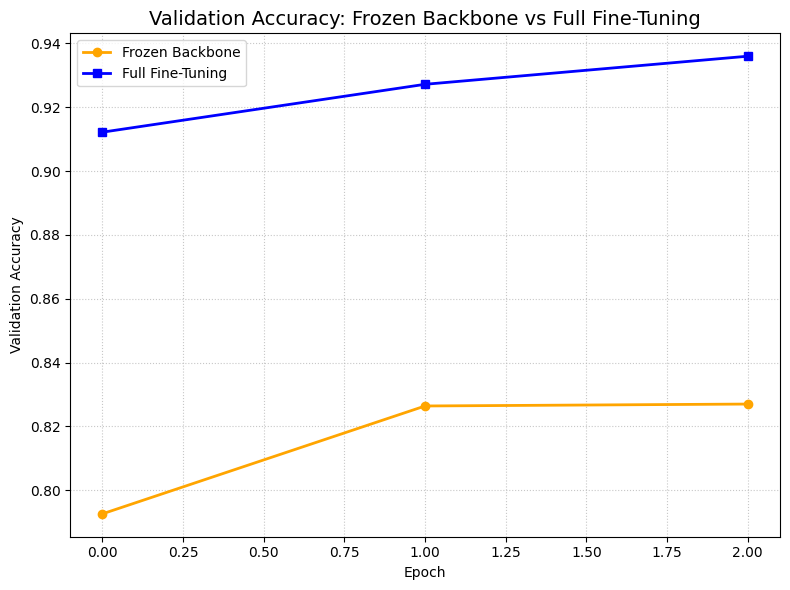

In [37]:
plt.figure(figsize=(8, 6))
plt.title("Validation Accuracy: Frozen Backbone vs Full Fine-Tuning", fontsize=14)
plt.plot(hist_frozen['val_acc'], label='Frozen Backbone', marker='o', color='orange', linewidth=2)
plt.plot(hist_finetune['val_acc'], label='Full Fine-Tuning', marker='s', color='blue', linewidth=2)
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.legend()
plt.grid(True, linestyle=':', alpha=0.7)
plt.tight_layout()
plt.show()

### Required Discussion (Task 3)

* **Which setup worked better:**
  Full fine-tuning (Model B) osiągnął lepsze wyniki (niższy loss, wyższe accuracy).

* **Whether fine-tuning improved the result enough to justify the extra training cost:**
   Pełen fine-tuning (Model B) podniósł dokładność walidacyjną z 82.7% aż do 93.6% oraz drastycznie obniżył loss (z 0.48 na 0.19). Choć wymagało to trenowania 1.5 miliona parametrów zamiast zaledwie 10 tysięcy (co zwiększa zapotrzebowanie sprzętowe), taki wzrost skuteczności usprawiedliwia ten koszt w docelowym modelu.

* **Which setup you would choose in practice:**
  W praktyce użyłbym **podejścia hybrydowego**. Najpierw trenuję tylko nową, zamrożoną głowę (chroni to resztę sieci przed drastycznymi zmianami wag na start), a potem "odmrażam" całą sieć i dotrenowuję ją (fine-tuning) z bardzo małym learning rate (np. `1e-4`).